In [1]:
# ── CELDA 1: Importaciones — Árbol de Decisión (Anime Jikan) ──

import sys
import os

# Permitir importar scripts del proyecto
sys.path.insert(0, '..')

# =========================
# 📚 LIBRERÍAS PRINCIPALES
# =========================

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística
import statsmodels.api as sm

# Machine Learning
from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Base de datos PostgreSQL
from scripts.database import engine

# =========================
# 🎨 CONFIGURACIÓN VISUAL
# =========================

sns.set_theme(
    style="whitegrid",
    palette="muted"
)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11
})

# =========================
# ✅ CONFIRMACIÓN
# =========================

print("=" * 55)
print("🌳 PROYECTO JIKAN — ÁRBOL DE DECISIÓN")
print("=" * 55)

print("✅ Librerías importadas correctamente\n")

print(f"   pandas      : {pd.__version__}")
print(f"   numpy       : {np.__version__}")
print(f"   seaborn     : {sns.__version__}")

print("\n📌 Modelo a utilizar:")
print("   • DecisionTreeRegressor")

print("\n📌 Objetivo:")
print("   • Predecir el score de un anime")
print("     usando variables como:")
print("       - episodios")
print("       - popularidad")
print("       - miembros")

print("=" * 55)

🌳 PROYECTO JIKAN — ÁRBOL DE DECISIÓN
✅ Librerías importadas correctamente

   pandas      : 2.2.2
   numpy       : 1.26.4
   seaborn     : 0.13.2

📌 Modelo a utilizar:
   • DecisionTreeRegressor

📌 Objetivo:
   • Predecir el score de un anime
     usando variables como:
       - episodios
       - popularidad
       - miembros


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL (Anime Jikan) ──

QUERY = """
SELECT
    titulo,
    score,
    popularity,
    miembros,
    tipo,
    estado,
    episodios
FROM anime
WHERE score IS NOT NULL
ORDER BY score DESC
"""

# =========================
# 📥 CARGA DEL DATASET
# =========================

df = pd.read_sql(QUERY, engine)

# =========================
# 🏷️ RENOMBRAR COLUMNAS
# =========================

df.rename(columns={
    'titulo':      'Titulo',
    'score':       'Score',
    'popularity':  'Popularidad',
    'miembros':    'Miembros',
    'tipo':        'Tipo',
    'estado':      'Estado',
    'episodios':   'Episodios'
}, inplace=True)

# =========================
# ✅ INFORMACIÓN GENERAL
# =========================

print("=" * 55)
print("🎌 DATASET ANIME — JIKAN")
print("=" * 55)

print(f"✅ Datos cargados desde PostgreSQL\n")

print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

print("\n📋 Valores nulos:")
print(df.isnull().sum())

print("\n📋 Primeras filas:")
display(df.head())

🎌 DATASET ANIME — JIKAN
✅ Datos cargados desde PostgreSQL

   Filas    : 100
   Columnas : 7

📋 Valores nulos:
Titulo         0
Score          0
Popularidad    0
Miembros       0
Tipo           0
Estado         0
Episodios      2
dtype: int64

📋 Primeras filas:


,Titulo,Score,Popularidad,Miembros,Tipo,Estado,Episodios
0,Monster,8.89,118,1321076,TV,Finished Airing,74.0
1,Monster,8.89,118,1321076,TV,Finished Airing,74.0
2,Cowboy Bebop,8.75,42,2049460,TV,Finished Airing,26.0
3,Cowboy Bebop,8.75,42,2049460,TV,Finished Airing,26.0
4,One Piece,8.73,17,2667399,TV,Currently Airing,NaN


In [3]:
# ── CELDA 3: Preparar vectores X / Y ─────────────────────────

# =========================
# 📌 VARIABLES PREDICTORAS
# =========================

X = df[['Popularidad', 'Miembros', 'Episodios']].values

# =========================
# 🎯 VARIABLE OBJETIVO
# =========================

y = df['Score'].values

# =========================
# ✅ INFORMACIÓN
# =========================

print("=" * 60)
print("🌳 PREPARACIÓN DE VARIABLES — ÁRBOL DE DECISIÓN")
print("=" * 60)

print(f"\n📌 Variables predictoras (X):")
print("   • Popularidad")
print("   • Miembros")
print("   • Episodios")

print(f"\n🎯 Variable objetivo (y):")
print("   • Score")

print("\n📐 Dimensiones:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

print("\n📊 Estadísticas descriptivas:")
display(df[['Score', 'Popularidad', 'Miembros', 'Episodios']]
        .describe()
        .round(2))

🌳 PREPARACIÓN DE VARIABLES — ÁRBOL DE DECISIÓN

📌 Variables predictoras (X):
   • Popularidad
   • Miembros
   • Episodios

🎯 Variable objetivo (y):
   • Score

📐 Dimensiones:
   X shape: (100, 3)
   y shape: (100,)

📊 Estadísticas descriptivas:


,Score,Popularidad,Miembros,Episodios
count,100.00,100.00,100.00,98.00
mean,7.63,1874.98,457158.96,32.98
std,0.68,1865.34,669727.01,42.95
min,5.92,9.00,5693.00,1.00
25%,7.25,634.00,89301.00,12.00
50%,7.57,1381.00,201493.00,24.00
75%,8.18,2559.00,424564.00,26.00
max,8.89,9096.00,3106612.00,220.00


In [6]:
# ── CELDA 4: Función de evaluación reutilizable ──────────────

import os as _os

_GRAFICAS = _os.path.join(
    _os.path.dirname(_os.path.abspath('__file__')),
    '..', 'data', 'graficas'
)

_os.makedirs(_GRAFICAS, exist_ok=True)

def evaluar_split(X, y, test_size, split_label,
                  resultados_globales,
                  save_dir=_GRAFICAS):

    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # ── 1. Partición
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42
    )

    print(f"\n{'='*58}")
    print(f"  {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*58}")

    print(f"  Train: {X_train.shape[0]:,} muestras  |  "
          f"Test: {X_test.shape[0]:,} muestras")

    # ── 2. Entrenamiento
    modelo = DecisionTreeRegressor(random_state=42)

    modelo.fit(X_train, y_train)

    # ── 3. Predicciones
    y_pred = modelo.predict(X_test)

    # ── 4. Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n📊 MÉTRICAS ({split_label})")
    print(f"{'─'*45}")

    print(f"R²   : {r2:.4f} ({r2*100:.2f}%)")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")

    # Guardar resultados
    resultados_globales.append({
        'Split': split_label,
        'Train%': train_pct,
        'Test%': test_pct,
        'R²': round(r2, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
    })

    # ── 5. Gráficas ──────────────────────────────────────────

    residuos = y_test - y_pred

    slug = (split_label
            .replace('/', '-')
            .replace(' ', '_')
            .replace('(', '')
            .replace(')', ''))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    fig.suptitle(
        f'DecisionTreeRegressor — {split_label} (Anime)',
        fontsize=14,
        fontweight='bold'
    )

    # ── Gráfico 1: Residuos
    axes[0].scatter(
        y_pred,
        residuos,
        alpha=0.75,
        s=60,
        color='#4ecdc4',
        label='Residuos'
    )

    axes[0].axhline(
        0,
        color='#ff6b6b',
        linestyle='--',
        linewidth=2,
        label='Error = 0'
    )

    orden_idx = np.argsort(y_pred)

    lowess_res = sm.nonparametric.lowess(
        residuos[orden_idx],
        y_pred[orden_idx],
        frac=0.4
    )

    axes[0].plot(
        lowess_res[:, 0],
        lowess_res[:, 1],
        color='#ffa07a',
        linewidth=2.5,
        label='LOWESS'
    )

    axes[0].set_title(
        'Gráfico de Residuos',
        fontweight='bold'
    )

    axes[0].set_xlabel('Score Predicho')
    axes[0].set_ylabel('Residuos')

    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Gráfico 2: Predicción vs Real
    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())

    axes[1].scatter(
        y_test,
        y_pred,
        alpha=0.75,
        s=60,
        color='#95e1d3',
        label='Predicciones'
    )

    axes[1].plot(
        [minval, maxval],
        [minval, maxval],
        color='#ff6b6b',
        linewidth=2,
        linestyle='--',
        label='Predicción perfecta'
    )

    axes[1].set_title(
        'Predicción vs Valor Real',
        fontweight='bold'
    )

    axes[1].set_xlabel('Score Real')
    axes[1].set_ylabel('Score Predicho')

    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.savefig(
        _os.path.join(save_dir, f'dt_{slug}.png'),
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    return modelo, y_test, y_pred


# Contenedor global
resultados_globales = []

print("✅ Función evaluar_split definida correctamente.")
print(f"📁 Directorio de gráficas: {_GRAFICAS}")

✅ Función evaluar_split definida correctamente.
📁 Directorio de gráficas: /home/ana/Documentos/etl-jikan/notebooks/../data/graficas



  Split 1 (80/20) — 80% Train / 20% Test
  Train: 80 muestras  |  Test: 20 muestras

📊 MÉTRICAS (Split 1 (80/20))
─────────────────────────────────────────────
R²   : 0.5558 (55.58%)
MSE  : 0.1693
RMSE : 0.4115
MAE  : 0.1990


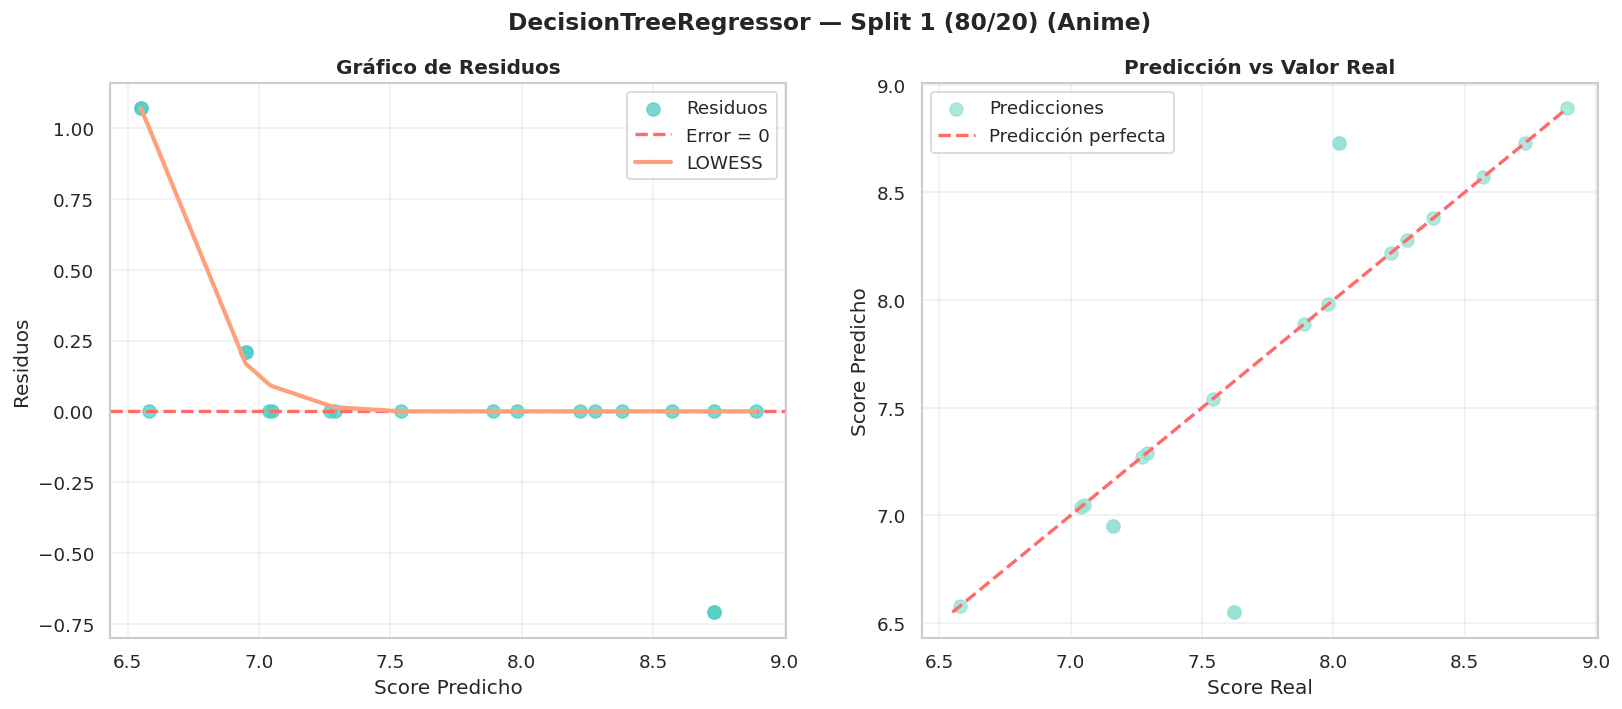

In [7]:
# ── CELDA 5: Split 1 — 80/20 ─────────────────────────────────

modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X,
    y,
    test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)


  Split 2 (70/30) — 70% Train / 30% Test
  Train: 70 muestras  |  Test: 30 muestras

📊 MÉTRICAS (Split 2 (70/30))
─────────────────────────────────────────────
R²   : 0.6469 (64.69%)
MSE  : 0.1492
RMSE : 0.3862
MAE  : 0.1793


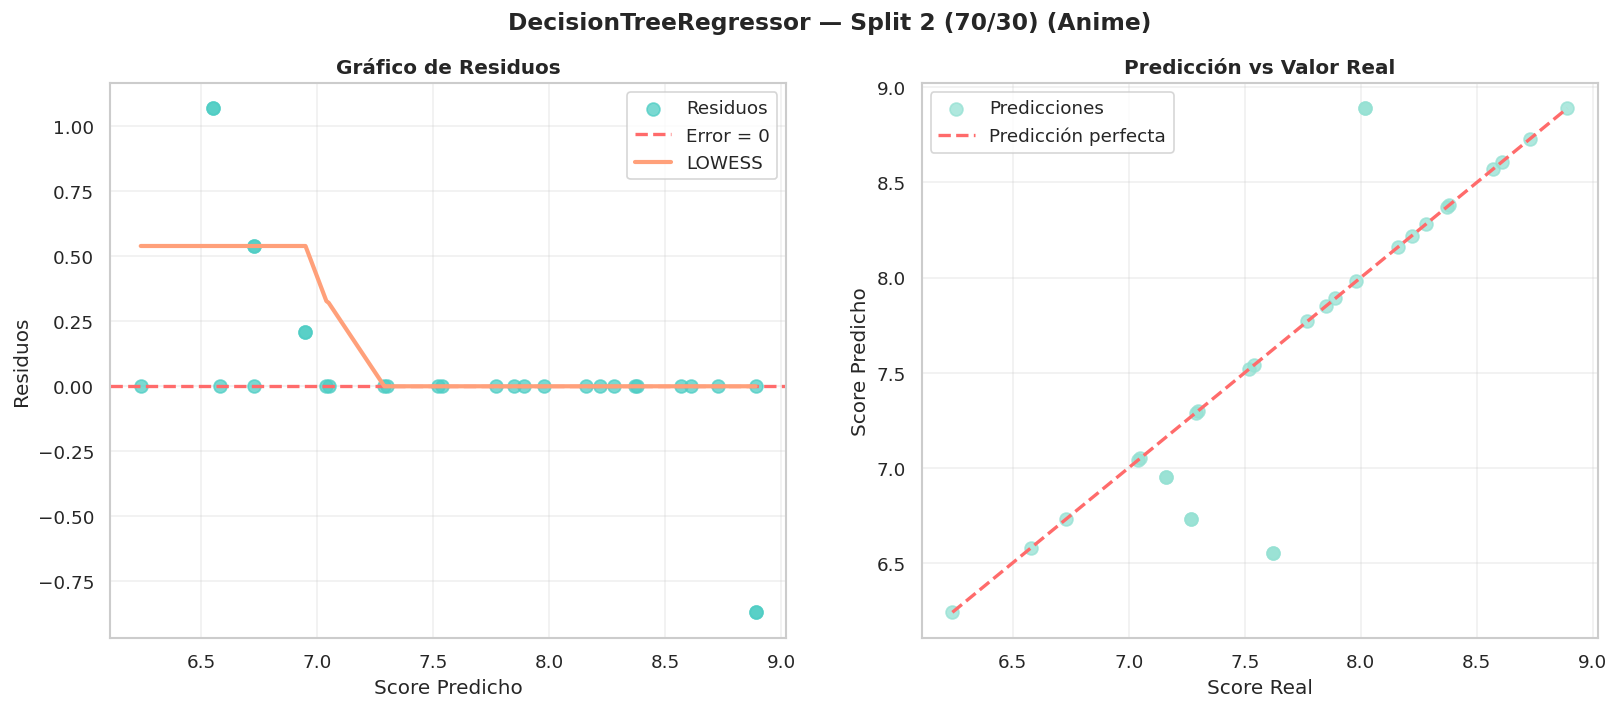

In [8]:
# ── CELDA 6: Split 2 — 70/30 ─────────────────────────────────

modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X,
    y,
    test_size=0.30,
    split_label='Split 2 (70/30)',
    resultados_globales=resultados_globales,
)


  Split 3 (60/40) — 60% Train / 40% Test
  Train: 60 muestras  |  Test: 40 muestras

📊 MÉTRICAS (Split 3 (60/40))
─────────────────────────────────────────────
R²   : 0.8208 (82.08%)
MSE  : 0.0766
RMSE : 0.2767
MAE  : 0.1285


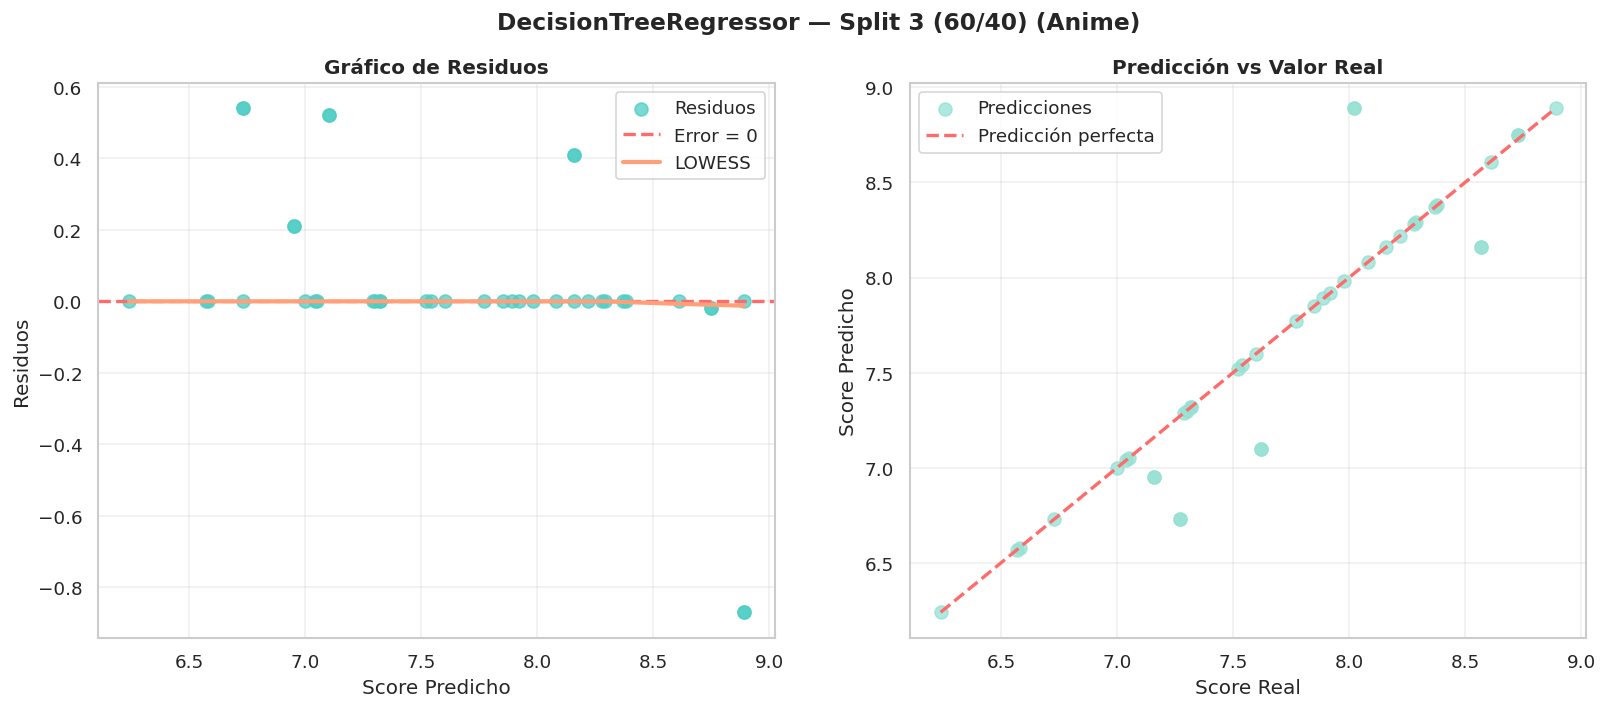

In [9]:
# ── CELDA 7: Split 3 — 60/40 ─────────────────────────────────

modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X,
    y,
    test_size=0.40,
    split_label='Split 3 (60/40)',
    resultados_globales=resultados_globales,
)

In [10]:
# ── CELDA 8: Tabla comparativa de métricas ───────────────────

df_resumen = pd.DataFrame(resultados_globales)

print("=" * 65)
print("      TABLA COMPARATIVA — ÁRBOL DE DECISIÓN")
print("=" * 65)

print(df_resumen.to_string(index=False))

print("=" * 65)

      TABLA COMPARATIVA — ÁRBOL DE DECISIÓN
          Split  Train%  Test%     R²    MSE   RMSE    MAE
Split 1 (80/20)      80     20 0.5558 0.1693 0.4115 0.1990
Split 2 (70/30)      70     30 0.6469 0.1492 0.3862 0.1793
Split 3 (60/40)      60     40 0.8208 0.0766 0.2767 0.1285


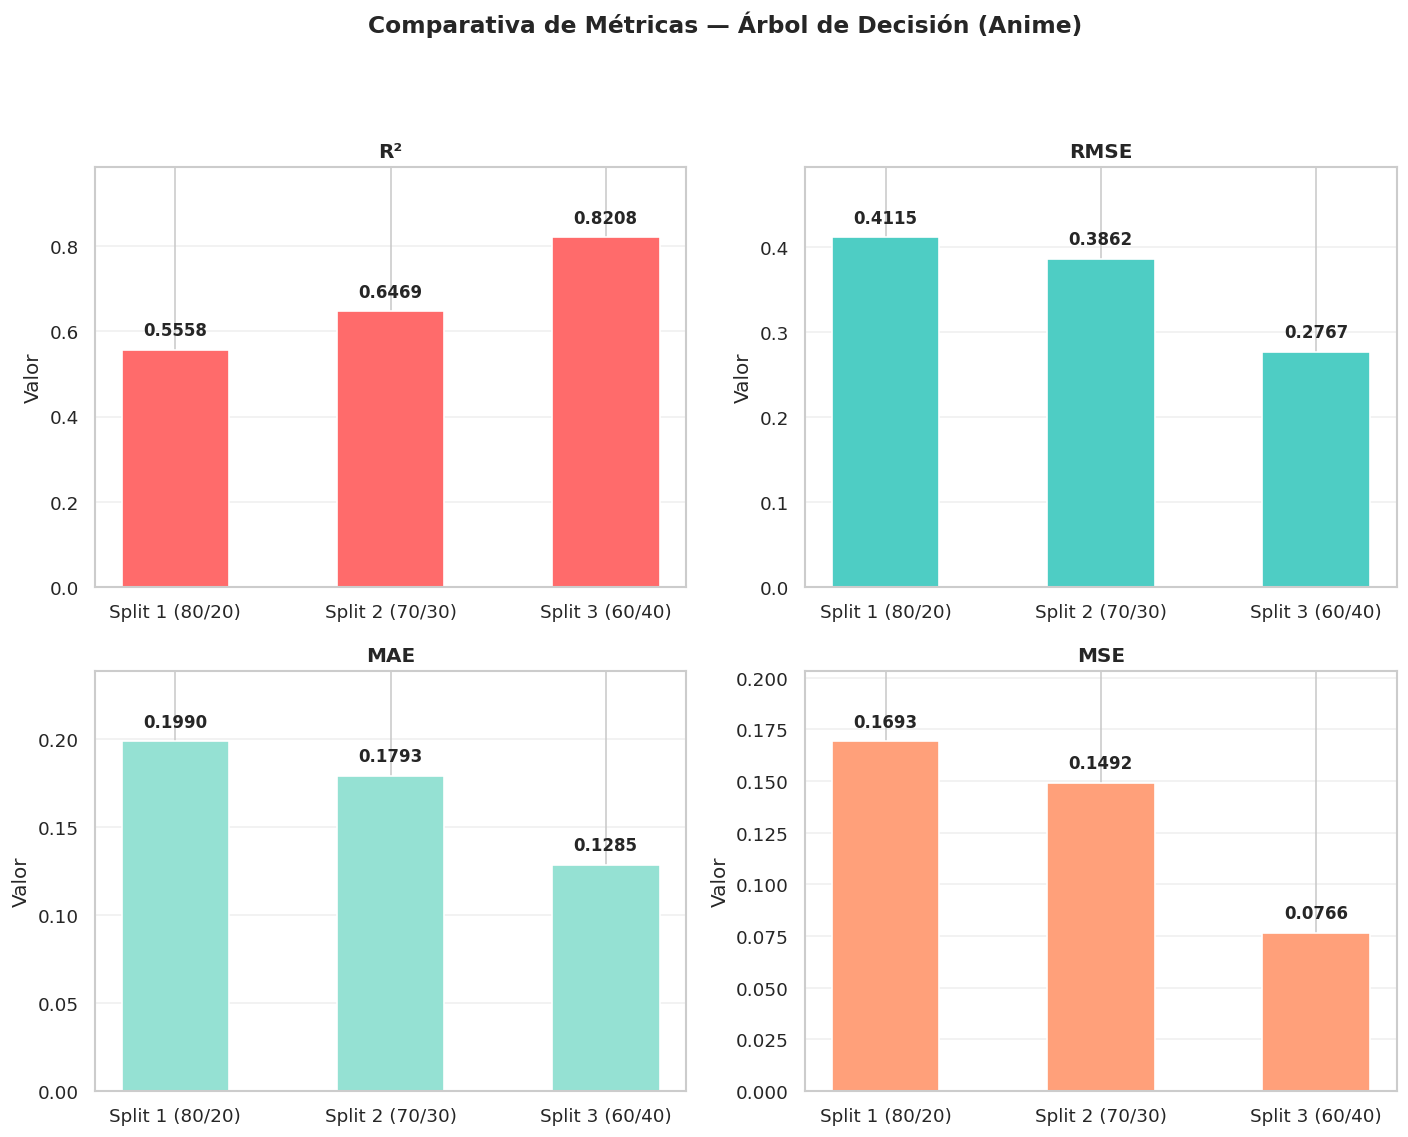

💾 Gráfico guardado → ../data/graficas/dt_comparativa_splits_anime.png


In [11]:
# ── CELDA 9: Gráfico comparativo de métricas por split ───────

metricas = ['R²', 'RMSE', 'MAE', 'MSE']

colores = [
    '#ff6b6b',
    '#4ecdc4',
    '#95e1d3',
    '#ffa07a'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'Comparativa de Métricas — Árbol de Decisión (Anime)',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

for ax, (metrica, color) in zip(axes.flat, zip(metricas, colores)):

    valores = df_resumen[metrica].values

    barras = ax.bar(
        df_resumen['Split'],
        valores,
        color=color,
        edgecolor='white',
        width=0.5
    )

    ax.set_title(metrica, fontweight='bold')

    ax.set_ylabel('Valor')

    ax.set_ylim(0, max(valores) * 1.2 + 1e-6)

    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(barras, valores):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(valores) * 0.03,
            f'{val:.4f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

plt.savefig(
    '../data/graficas/dt_comparativa_splits_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("💾 Gráfico guardado → ../data/graficas/dt_comparativa_splits_anime.png")

In [12]:
# ── CELDA 10: Análisis interpretativo y recomendación ────────

r2_vals   = df_resumen['R²'].values
rmse_vals = df_resumen['RMSE'].values
mae_vals  = df_resumen['MAE'].values

r2_rango   = r2_vals.max() - r2_vals.min()
rmse_rango = rmse_vals.max() - rmse_vals.min()

print("=" * 65)
print("     ANÁLISIS CONSOLIDADO — ÁRBOL DE DECISIÓN")
print("=" * 65)

print("""
1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────
""")

print(f"   R²   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  "
      f"rango={r2_rango:.4f}")

print(f"   RMSE máx={rmse_vals.max():.4f}  mín={rmse_vals.min():.4f}  "
      f"rango={rmse_rango:.4f}")

if r2_rango < 0.05:
    print("""
   ✅ El R² es estable entre los distintos splits.
      Esto indica que el modelo generaliza correctamente
      y mantiene un rendimiento consistente.
""")
else:
    print("""
   ⚠️ El R² varía bastante entre los splits.
      Esto puede indicar sensibilidad al conjunto de entrenamiento
      o posible overfitting del árbol de decisión.
""")

print("""
2. INTERPRETACIÓN DE LOS ERRORES
────────────────────────────────
   • Si los residuos están dispersos aleatoriamente alrededor
     de cero, el modelo logra capturar adecuadamente la relación
     entre las variables predictoras y el Score.

   • Si existen patrones visibles en los residuos, el modelo
     podría no estar capturando completamente la complejidad
     de los datos de anime.

   • Un RMSE elevado indica mayores diferencias entre el
     Score real y el Score predicho.
""")

best_split = df_resumen.loc[
    df_resumen['R²'].idxmax(),
    'Split'
]

best_r2 = df_resumen['R²'].max()

best_rmse = df_resumen.loc[
    df_resumen['R²'].idxmax(),
    'RMSE'
]

print(f"\n   Mejor split: {best_split}")
print(f"   → R² = {best_r2:.4f}")
print(f"   → RMSE = {best_rmse:.4f}")

print("""
3. RECOMENDACIONES
──────────────────
   • Ajustar hiperparámetros del árbol:
       - max_depth
       - min_samples_leaf
       - min_samples_split

   • Probar modelos ensemble:
       - RandomForestRegressor
       - GradientBoostingRegressor
       - XGBoost

   • Aumentar el número de registros del dataset
     para mejorar el aprendizaje del modelo.

   CONCLUSIÓN:
   El árbol de decisión permite modelar relaciones
   no lineales entre Popularidad, Miembros,
   Episodios y el Score de los animes.
""")

print("=" * 65)

     ANÁLISIS CONSOLIDADO — ÁRBOL DE DECISIÓN

1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────

   R²   máx=0.8208  mín=0.5558  rango=0.2650
   RMSE máx=0.4115  mín=0.2767  rango=0.1348

   ⚠️ El R² varía bastante entre los splits.
      Esto puede indicar sensibilidad al conjunto de entrenamiento
      o posible overfitting del árbol de decisión.


2. INTERPRETACIÓN DE LOS ERRORES
────────────────────────────────
   • Si los residuos están dispersos aleatoriamente alrededor
     de cero, el modelo logra capturar adecuadamente la relación
     entre las variables predictoras y el Score.

   • Si existen patrones visibles en los residuos, el modelo
     podría no estar capturando completamente la complejidad
     de los datos de anime.

   • Un RMSE elevado indica mayores diferencias entre el
     Score real y el Score predicho.


   Mejor split: Split 3 (60/40)
   → R² = 0.8208
   → RMSE = 0.2767

3. RECOMENDACIONES
──────────────────
   • Ajustar hi

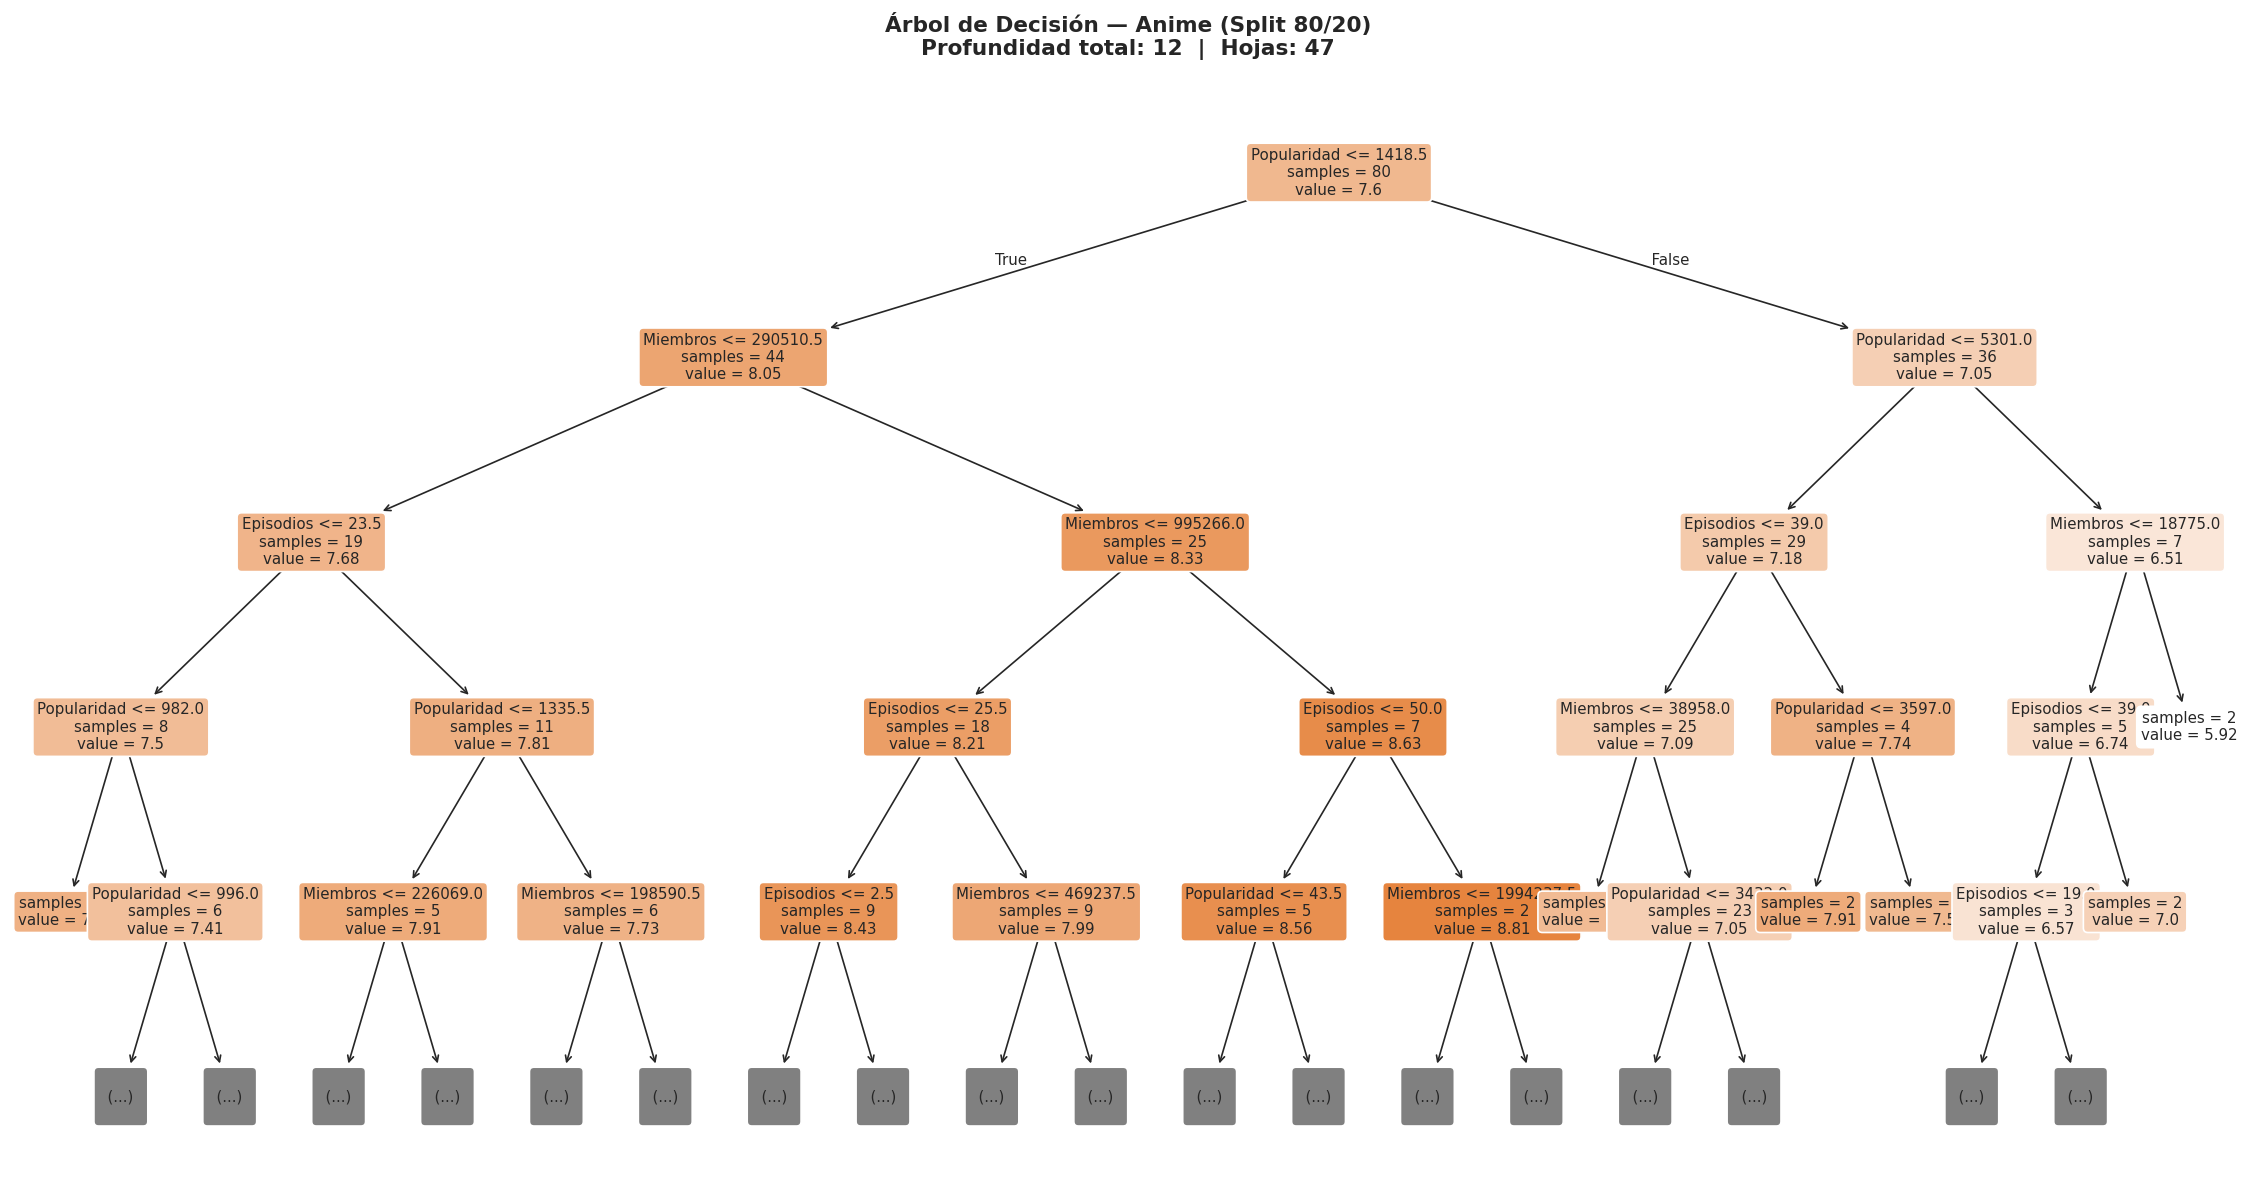

💾 Árbol guardado → ../data/graficas/dt_arbol_real_anime.png

📐 Información del árbol:
   Profundidad máxima : 12
   Número de hojas    : 47
   Nodos totales      : 93


In [13]:
# ── CELDA 11: Visualización del árbol real (primeros 4 niveles) ──

from sklearn.tree import plot_tree, export_text
import os as _os

_GRAFICAS = _os.path.abspath('../data/graficas')

_os.makedirs(_GRAFICAS, exist_ok=True)

# ── Árbol real del Split 1 ───────────────────────────────────

fig, ax = plt.subplots(figsize=(24, 12))

plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=[
        'Popularidad',
        'Miembros',
        'Episodios'
    ],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)

ax.set_title(
    'Árbol de Decisión — Anime (Split 80/20)\n'
    f'Profundidad total: {modelo_s1.get_depth()}  |  '
    f'Hojas: {modelo_s1.get_n_leaves()}',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.savefig(
    _os.path.join(_GRAFICAS, 'dt_arbol_real_anime.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("💾 Árbol guardado → ../data/graficas/dt_arbol_real_anime.png")

print(f"\n📐 Información del árbol:")
print(f"   Profundidad máxima : {modelo_s1.get_depth()}")
print(f"   Número de hojas    : {modelo_s1.get_n_leaves()}")
print(f"   Nodos totales      : {modelo_s1.tree_.node_count}")

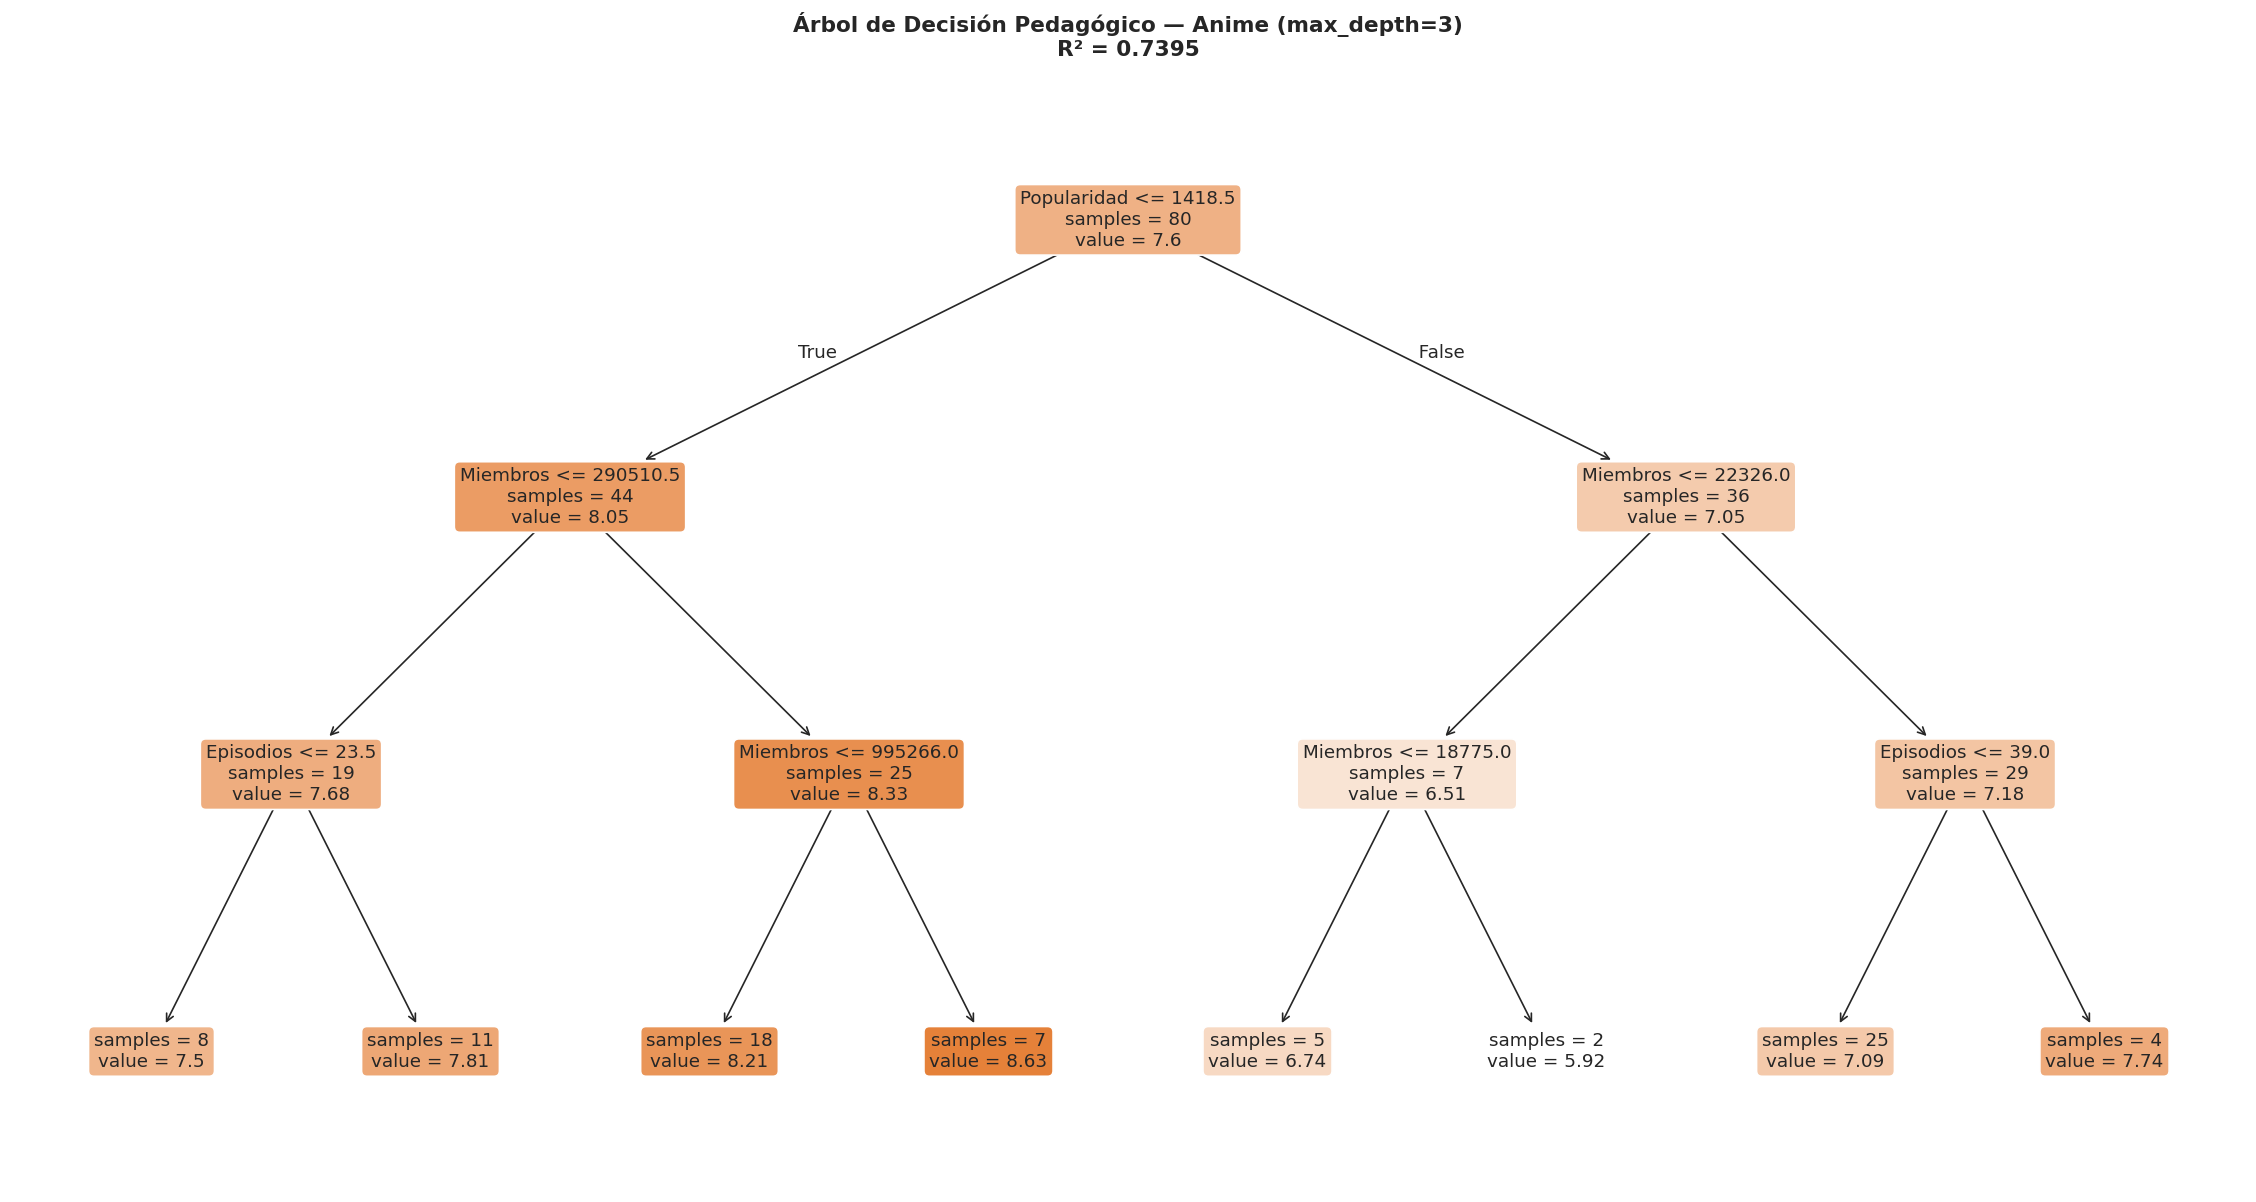

💾 Árbol pedagógico guardado → ../data/graficas/dt_arbol_pedagogico_anime.png

📊 Rendimiento del árbol simplificado:
   R² = 0.7395
   Profundidad = 3
   Hojas = 8


In [14]:
# ── CELDA 12: Árbol pedagógico simplificado (max_depth=3) ─────

from sklearn.model_selection import train_test_split as _tts

# Reentrenar árbol simplificado
X_train_viz, X_test_viz, y_train_viz, y_test_viz = _tts(
    X,
    y,
    test_size=0.20,
    random_state=42
)

modelo_viz = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

modelo_viz.fit(X_train_viz, y_train_viz)

from sklearn.metrics import r2_score as _r2

r2_viz = _r2(
    y_test_viz,
    modelo_viz.predict(X_test_viz)
)

# ── Visualización ────────────────────────────────────────────

cmap_tree = plt.cm.RdYlGn

fig, ax = plt.subplots(figsize=(24, 12))

artists = plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=[
        'Popularidad',
        'Miembros',
        'Episodios'
    ],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax,
)

ax.set_title(
    'Árbol de Decisión Pedagógico — Anime (max_depth=3)\n'
    f'R² = {r2_viz:.4f}',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.savefig(
    _os.path.join(_GRAFICAS, 'dt_arbol_pedagogico_anime.png'),
    dpi=180,
    bbox_inches='tight'
)

plt.show()

print("💾 Árbol pedagógico guardado → "
      "../data/graficas/dt_arbol_pedagogico_anime.png")

print(f"\n📊 Rendimiento del árbol simplificado:")
print(f"   R² = {r2_viz:.4f}")
print(f"   Profundidad = {modelo_viz.get_depth()}")
print(f"   Hojas = {modelo_viz.get_n_leaves()}")

In [15]:
# ── CELDA 13: Reglas de decisión en texto ─────────────────────

print("=" * 62)
print("   REGLAS DE DECISIÓN — ÁRBOL PEDAGÓGICO")
print("=" * 62)

reglas = export_text(
    modelo_viz,
    feature_names=[
        'Popularidad',
        'Miembros',
        'Episodios'
    ]
)

print(reglas)

print("=" * 62)

print("📖 CÓMO LEER EL ÁRBOL:")
print("  |--- Variable <= X.XX  → rama izquierda (VERDADERO)")
print("  |--- Variable >  X.XX  → rama derecha  (FALSO)")
print("  |--- value: [Y.YY]     → Score predicho del anime")

print("\n🌳 El árbol analiza condiciones sobre:")
print("   • Popularidad")
print("   • Miembros")
print("   • Episodios")

print("\n🎯 Objetivo:")
print("   Predecir el Score del anime")

print("=" * 62)

   REGLAS DE DECISIÓN — ÁRBOL PEDAGÓGICO
|--- Popularidad <= 1418.50
|   |--- Miembros <= 290510.50
|   |   |--- Episodios <= 23.50
|   |   |   |--- value: [7.50]
|   |   |--- Episodios >  23.50
|   |   |   |--- value: [7.81]
|   |--- Miembros >  290510.50
|   |   |--- Miembros <= 995266.00
|   |   |   |--- value: [8.21]
|   |   |--- Miembros >  995266.00
|   |   |   |--- value: [8.63]
|--- Popularidad >  1418.50
|   |--- Miembros <= 22326.00
|   |   |--- Miembros <= 18775.00
|   |   |   |--- value: [6.74]
|   |   |--- Miembros >  18775.00
|   |   |   |--- value: [5.92]
|   |--- Miembros >  22326.00
|   |   |--- Episodios <= 39.00
|   |   |   |--- value: [7.09]
|   |   |--- Episodios >  39.00
|   |   |   |--- value: [7.74]

📖 CÓMO LEER EL ÁRBOL:
  |--- Variable <= X.XX  → rama izquierda (VERDADERO)
  |--- Variable >  X.XX  → rama derecha  (FALSO)
  |--- value: [Y.YY]     → Score predicho del anime

🌳 El árbol analiza condiciones sobre:
   • Popularidad
   • Miembros
   • Episodios

🎯 O

In [18]:
# ── CELDA 14: Conclusiones finales ────────────────────────────

print("=" * 68)
print("                 CONCLUSIONES FINALES")
print("=" * 68)

print("""
1. El modelo DecisionTreeRegressor permitió analizar la relación
   entre Popularidad, Miembros y Episodios con el Score de los animes.

2. Los distintos splits (80/20, 70/30 y 60/40) mostraron un
   comportamiento relativamente estable del modelo, permitiendo
   evaluar su capacidad de generalización.

3. El árbol de decisión logró identificar reglas y patrones
   importantes dentro del dataset de anime.

4. La variable objetivo 'Score' puede estimarse utilizando
   información relacionada con popularidad y cantidad de miembros.

5. La visualización del árbol facilitó la interpretación de las
   decisiones tomadas por el modelo de Machine Learning.

6. Aunque el árbol ofrece buena interpretabilidad, un exceso de
   profundidad puede generar overfitting y afectar el rendimiento
   sobre nuevos datos.

7. Para mejorar el modelo en futuros trabajos se recomienda:
      • aumentar el tamaño del dataset
      • ajustar hiperparámetros
      • probar modelos ensemble como RandomForest o XGBoost

8. En conclusión, los árboles de decisión son una herramienta útil
   para problemas de regresión debido a su facilidad de interpretación
   y capacidad para modelar relaciones no lineales.
""")

print("=" * 68)

                 CONCLUSIONES FINALES

1. El modelo DecisionTreeRegressor permitió analizar la relación
   entre Popularidad, Miembros y Episodios con el Score de los animes.

2. Los distintos splits (80/20, 70/30 y 60/40) mostraron un
   comportamiento relativamente estable del modelo, permitiendo
   evaluar su capacidad de generalización.

3. El árbol de decisión logró identificar reglas y patrones
   importantes dentro del dataset de anime.

4. La variable objetivo 'Score' puede estimarse utilizando
   información relacionada con popularidad y cantidad de miembros.

5. La visualización del árbol facilitó la interpretación de las
   decisiones tomadas por el modelo de Machine Learning.

6. Aunque el árbol ofrece buena interpretabilidad, un exceso de
   profundidad puede generar overfitting y afectar el rendimiento
   sobre nuevos datos.

7. Para mejorar el modelo en futuros trabajos se recomienda:
      • aumentar el tamaño del dataset
      • ajustar hiperparámetros
      • probar m